In [1]:
!pip install pm4py seaborn graphviz




[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install matplotlib seaborn --only-binary=:all: -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




PM4Py 2.7.23.8
Загружено журналов: 3

1. БАЗОВЫЕ СТАТИСТИКИ

        схема  сессий  событий  ср. длина  мин. длина  макс. длина  доля ошибок, %  ср. длительность, мин
  simple_disk    1000   270506      270.5         105          517            19.1                   28.1
medium_memory    1000   277111      277.1         102          525            25.8                   28.8
   complex_os    1000   267163      267.2         104          443            24.5                   27.7


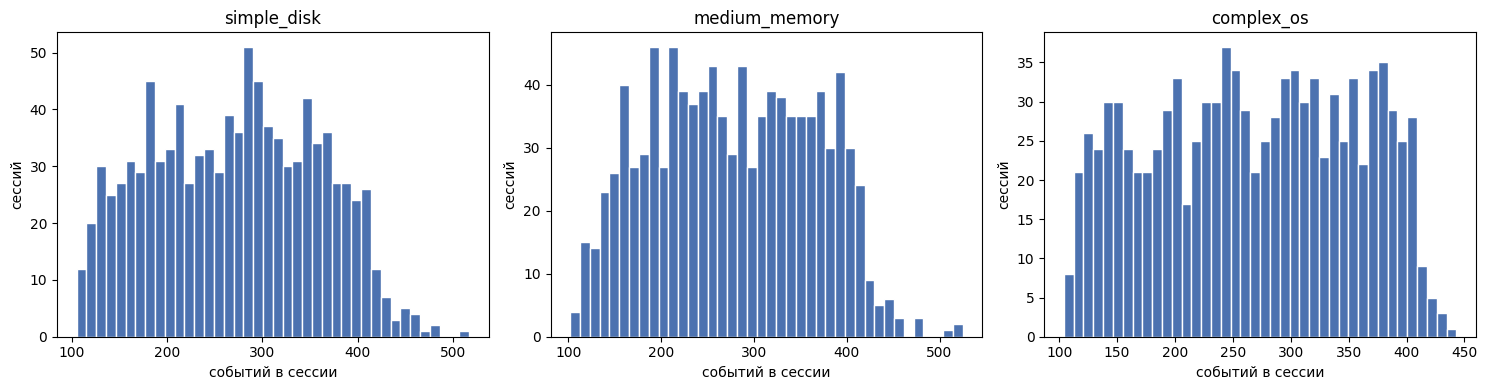

== simple_disk ==
event_id  activity         
1001      DiskPowerOn            1000
1002      DiskInit               1000
1003      DiskReadWrite        225241
1004      DiskIdle              42265
1005      DiskShutdownOk          809
1006      DiskCriticalError       191
Уровни: {'Information': 270315, 'Critical': 191}

== medium_memory ==
event_id  activity         
2001      MemPowerOn             1000
2002      MemControllerInit      1000
2003      MemDimmDetected        1000
2004      MemSelfTest            1000
2005      MemAccess            220118
2006      MemEccCorrected       41183
2007      MemNonFatalError       5405
2008      MemRecovered           5405
2009      MemShutdownOk           742
2010      MemFatalError           258
Уровни: {'Information': 230265, 'Warning': 46588, 'Critical': 258}

== complex_os ==
event_id  activity          
3001      OsBootStart             1000
3002      KernelInit              1000
3003      DriverLoad              1000
3004      Service

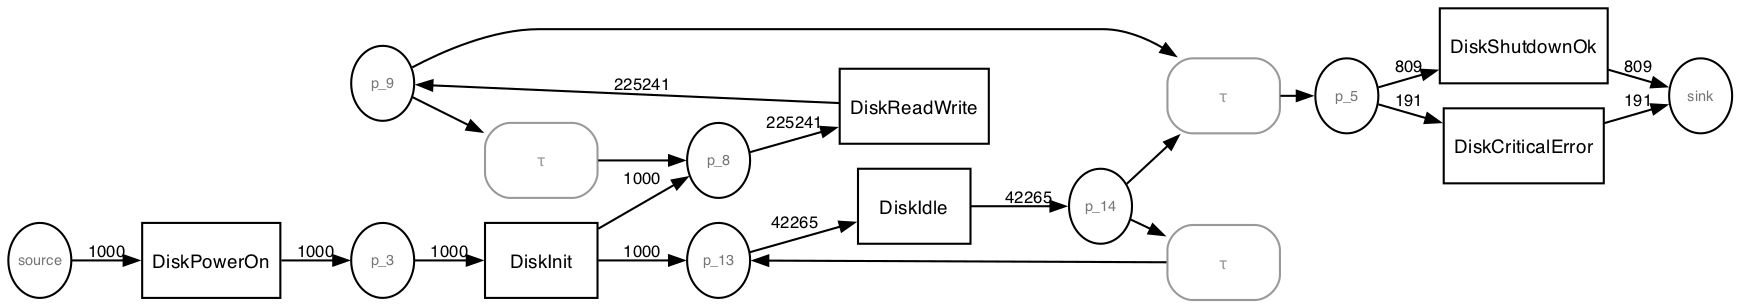

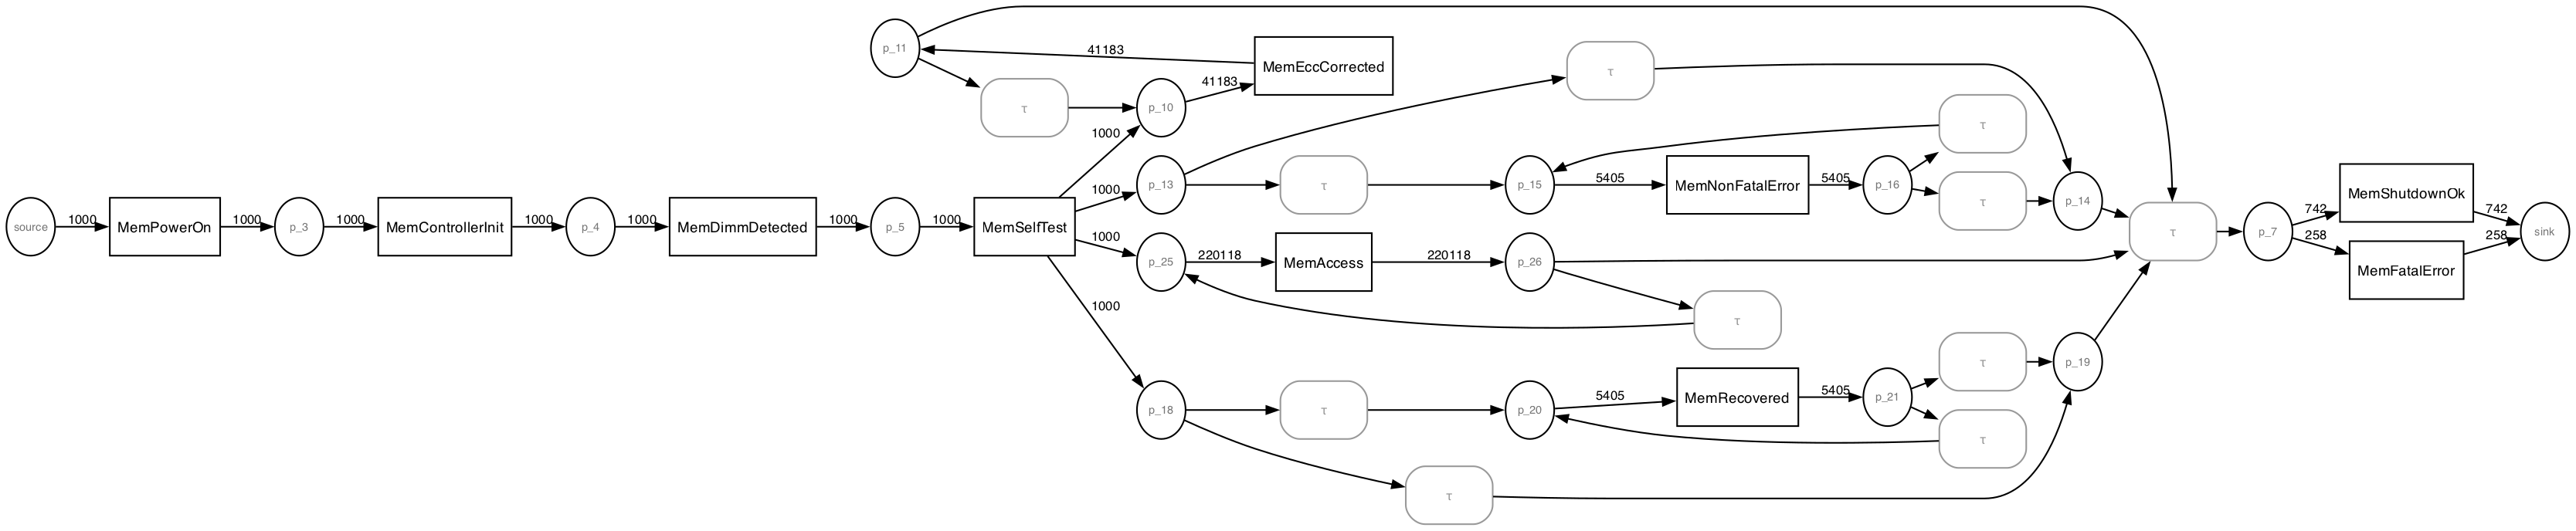

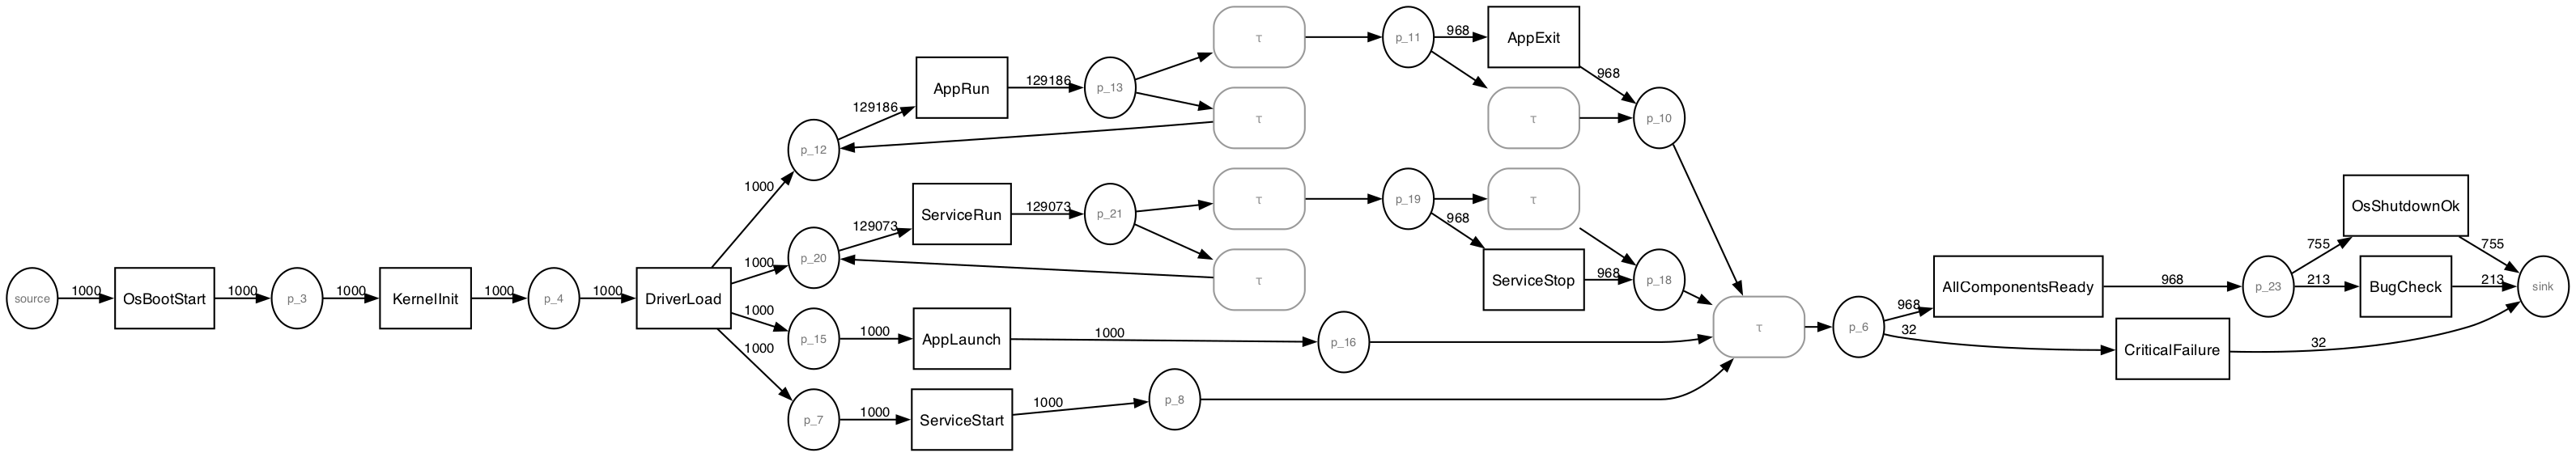

        схема  fitness (восстановленная модель)  мин. fitness
  simple_disk                               1.0           1.0
medium_memory                               1.0           1.0
   complex_os                               1.0           1.0
        схема  fitness (исходная модель)  мин. fitness
  simple_disk                        1.0           1.0
medium_memory                        1.0           1.0
   complex_os                        1.0           1.0
По source / channel:
source                   channel    
Application              Application    131154
Kernel-Power             System           4968
Service Control Manager  System         131041

Доля сессий с критической ошибкой: 24.5%
        схема  сессий  событий  ср. длина  мин. длина  макс. длина  доля ошибок, %  ср. длительность, мин  fitness (восстановленная модель)  мин. fitness_x  fitness (исходная модель)  мин. fitness_y
  simple_disk    1000   270506      270.5         105          517            19.1          

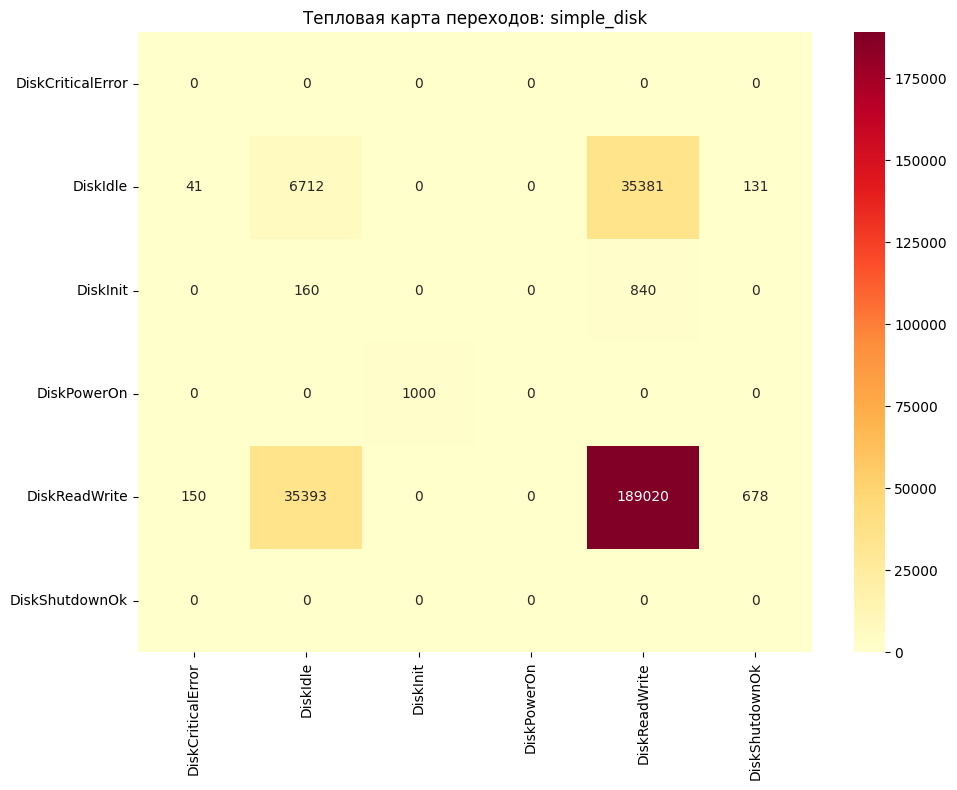

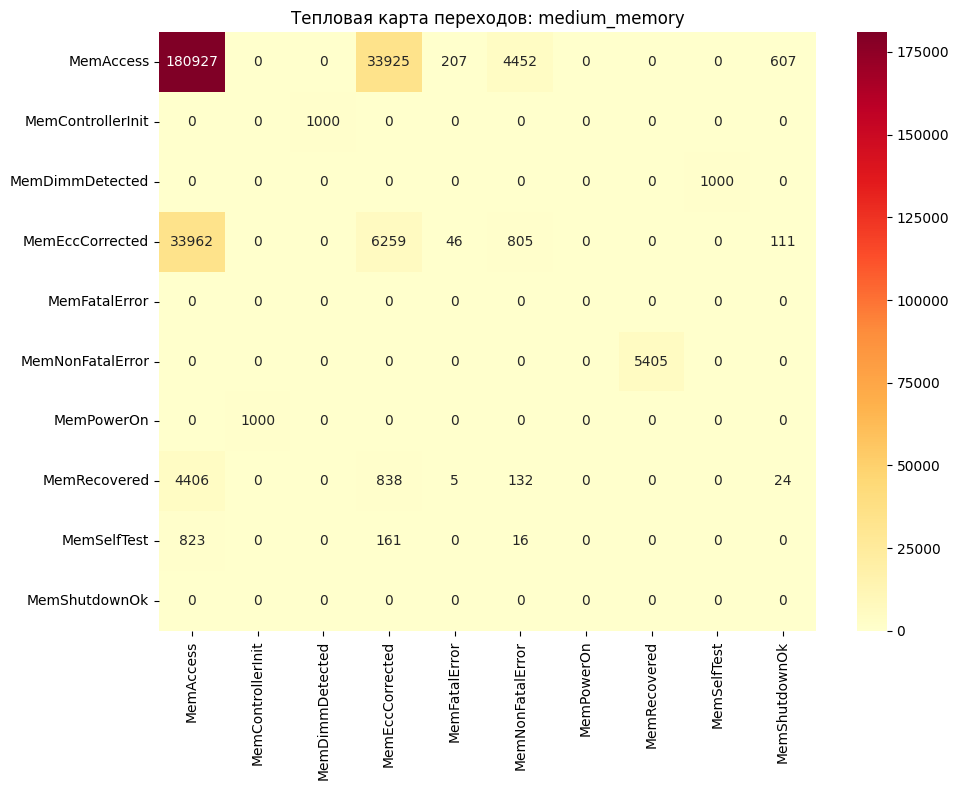

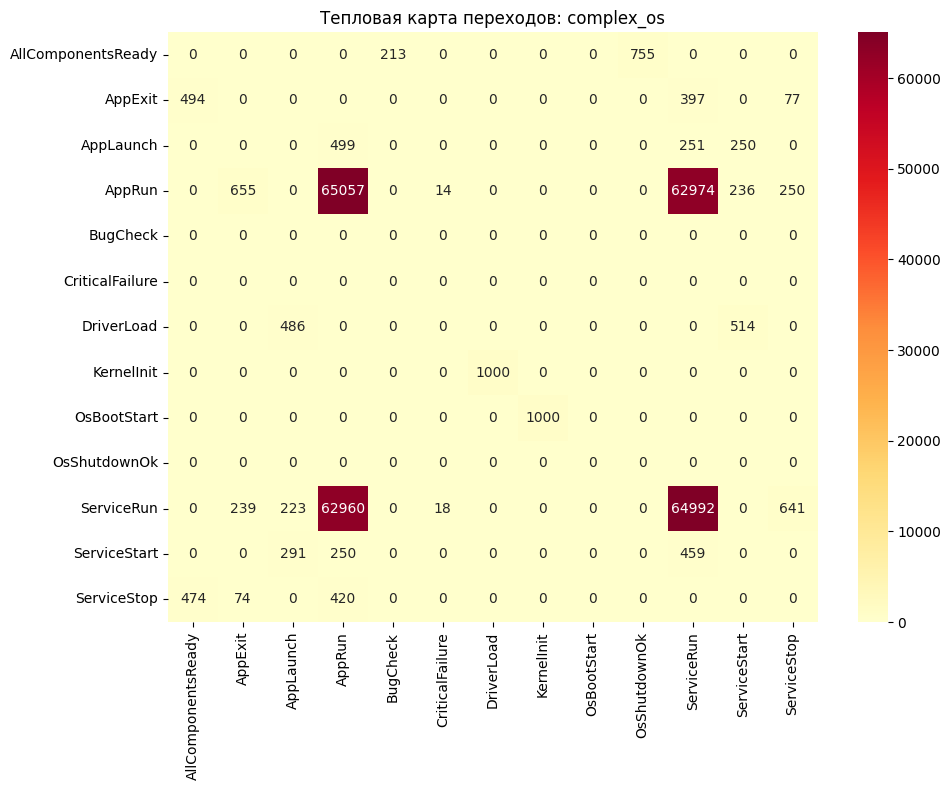


✅ АНАЛИЗ ЗАВЕРШЕН УСПЕШНО!


In [3]:
# ================= Установка зависимостей и импорты =================
import sys
import subprocess
for _pkg in ("pm4py", "graphviz"):
    try:
        __import__(_pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg])
import os
import statistics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pm4py
import pm4py.util.constants as _pconst
_pconst.SHOW_PROGRESS_BAR = False          # отключаем прогресс-бары PM4Py
from IPython.display import Image, display
print("PM4Py", pm4py.__version__)

# ================= Конфигурация =================
LOGS = {
    "simple_disk":   "log_simple_disk.csv",
    "medium_memory": "log_medium_memory.csv",
    "complex_os":    "log_complex_os.csv",
}
PNML = {
    "simple_disk":   "scheme_simple_disk.pnml",
    "medium_memory": "scheme_medium_memory.pnml",
    "complex_os":    "scheme_complex_os.pnml",
}
# event_id событий критической ошибки (для каждой схемы)
END_ERR = {
    "simple_disk":   {1006},
    "medium_memory": {2010},
    "complex_os":    {3012, 3013},
}

# ================= Загрузка данных =================
def load_log(path):
    """CSV -> DataFrame с PM4Py-колонками -> EventLog."""
    df = pd.read_csv(path)
    df = pm4py.format_dataframe(df, case_id="session_id",
                                activity_key="activity", timestamp_key="timestamp")
    return df, pm4py.convert_to_event_log(df)
LOGS_DATA = {}
for key, path in LOGS.items():
    if os.path.exists(path):
        LOGS_DATA[key] = load_log(path)
missing = [p for p in list(LOGS.values()) + list(PNML.values()) if not os.path.exists(p)]
if missing:
    print("ВНИМАНИЕ: сначала выполните блокнот 01 (не найдены файлы):", missing)
print("Загружено журналов:", len(LOGS_DATA))

# ================= 1. Базовые статистики =================
stats_rows = []
for key, (df, log) in LOGS_DATA.items():
    lengths = df.groupby("case:concept:name").size()
    last = df.groupby("case:concept:name")["event_id"].last()
    err_rate = last.isin(END_ERR[key]).mean()
    dur = (df.groupby("case:concept:name")["time:timestamp"]
             .agg(lambda s: (s.max() - s.min()).total_seconds() / 60.0))
    stats_rows.append({
        "схема": key,
        "сессий": len(log),
        "событий": sum(len(t) for t in log),
        "ср. длина": round(lengths.mean(), 1),
        "мин. длина": int(lengths.min()),
        "макс. длина": int(lengths.max()),
        "доля ошибок, %": round(100 * err_rate, 1),
        "ср. длительность, мин": round(dur.mean(), 1),
    })
stats = pd.DataFrame(stats_rows)
print("\n" + "="*60)
print("1. БАЗОВЫЕ СТАТИСТИКИ")
print("="*60 + "\n")
print(stats.to_string(index=False))

# ================= 2. Распределение длины сессий =================
fig, axes = plt.subplots(1, len(LOGS_DATA), figsize=(15, 4))
if len(LOGS_DATA) == 1:
    axes = [axes]
for ax, (key, (df, log)) in zip(axes, LOGS_DATA.items()):
    lengths = df.groupby("case:concept:name").size()
    ax.hist(lengths, bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(key)
    ax.set_xlabel("событий в сессии")
    ax.set_ylabel("сессий")
plt.tight_layout()
plt.savefig("fig_lengths.png", dpi=110)
plt.show()

# ================= 3. Распределение событий по типам =================
for key, (df, log) in LOGS_DATA.items():
    print("==", key, "==")
    print(df.groupby(["event_id", "activity"]).size().to_string())
    print("Уровни:", df["level"].value_counts().to_dict())
    print()

# ================= 4. Process Discovery =================
# Модель рисуется средствами Graphviz (как в отчёте, рис. 5–7):
# τ — белые прямоугольники без чёрных квадратов, на дугах — количество
# срабатываний перехода в журнале.
import graphviz as gv
from pm4py.objects.petri_net.obj import PetriNet
Place, Transition = PetriNet.Place, PetriNet.Transition

def draw_imf(key, df, net):
    counts = df["activity"].value_counts().to_dict()
    g = gv.Digraph(format="png")
    g.attr(rankdir="LR", dpi="150", ranksep="0.20", nodesep="0.16", bgcolor="white")
    g.attr("node", fontname="Noto Sans")
    g.attr("edge", fontname="Noto Sans", fontsize="8", arrowsize="0.7")
    for p in net.places:
        g.node("p_" + p.name, label=p.name, shape="ellipse",
               fontsize="7", fontcolor="#777777", width="0.42", fixedsize="true")
    for t in net.transitions:
        if t.label is None:
            g.node("t_" + t.name, label="τ", shape="box", style="rounded,filled",
                   fillcolor="white", color="#999999", fontcolor="#999999", fontsize="8")
        else:
            g.node("t_" + t.name, label=t.label, shape="box",
                   fontsize="9", margin="0.07,0.04")
    for a in net.arcs:
        src, dst = a.source, a.target
        sn = "p_" + src.name if isinstance(src, Place) else "t_" + src.name
        dn = "p_" + dst.name if isinstance(dst, Place) else "t_" + dst.name
        tr = src if isinstance(src, Transition) else (dst if isinstance(dst, Transition) else None)
        if tr is not None and tr.label is not None:
            g.edge(sn, dn, label=str(counts.get(tr.label, 0)))
        else:
            g.edge(sn, dn)
    png = "fig_discovered_{}.png".format(key)
    g.render(png[:-4], cleanup=True)
    return png

discovery_rows = []
for key, (df, log) in LOGS_DATA.items():
    net, im, fm = pm4py.discover_petri_net_inductive(log)
    png = draw_imf(key, df, net)
    display(Image(filename=png, width=850))
    fit = [d["trace_fitness"] for d in
           pm4py.conformance_diagnostics_token_based_replay(log, net, im, fm)]
    discovery_rows.append({
        "схема": key,
        "fitness (восстановленная модель)": round(statistics.mean(fit), 4),
        "мин. fitness": round(min(fit), 4),
    })
print(pd.DataFrame(discovery_rows).to_string(index=False))

# ================= 5. Conformance (исходная модель) =================
conf_rows = []
for key, pnml_path in PNML.items():
    if not os.path.exists(pnml_path):
        print(f"PNML не найден: {pnml_path}")
        continue
    if key not in LOGS_DATA:
        continue
    df, log = LOGS_DATA[key]
    net0, im0, fm0 = pm4py.read_pnml(pnml_path)
    fit = [d["trace_fitness"] for d in
           pm4py.conformance_diagnostics_token_based_replay(log, net0, im0, fm0)]
    conf_rows.append({
        "схема": key,
        "fitness (исходная модель)": round(statistics.mean(fit), 4),
        "мин. fitness": round(min(fit), 4),
    })
print(pd.DataFrame(conf_rows).to_string(index=False))

# ================= 6. Многокомпонентный анализ =================
if "complex_os" in LOGS_DATA:
    dfc = pd.read_csv(LOGS["complex_os"])
    print("По source / channel:")
    print(dfc.groupby(["source", "channel"]).size().to_string())
    print()
    print("Доля сессий с критической ошибкой: {:.1%}".format(
        dfc.groupby("session_id")["event_id"].last().isin(END_ERR["complex_os"]).mean()))

# ================= 7. Сводная таблица =================
summary = (stats
           .merge(pd.DataFrame(discovery_rows), on="схема", how="left")
           .merge(pd.DataFrame(conf_rows), on="схема", how="left"))
print(summary.to_string(index=False))

# ================= 8. Тепловая карта переходов =================
# В каждой ячейке указано количество переходов (как в отчёте, рис. 8–10).
for key, (df, log) in LOGS_DATA.items():
    transitions = {}
    for trace in log:
        events = [e["concept:name"] for e in trace if "concept:name" in e]
        for i in range(len(events) - 1):
            pair = (events[i], events[i+1])
            transitions[pair] = transitions.get(pair, 0) + 1
    if not transitions:
        print(f"{key}: нет переходов")
        continue
    all_acts = sorted(set([a for a, _ in transitions.keys()] + [b for _, b in transitions.keys()]))
    matrix = pd.DataFrame(0, index=all_acts, columns=all_acts)
    for (a, b), count in transitions.items():
        matrix.loc[a, b] = count
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".0f", cmap="YlOrRd",
                xticklabels=all_acts, yticklabels=all_acts)
    plt.title(f"Тепловая карта переходов: {key}")
    plt.tight_layout()
    plt.savefig(f"heatmap_{key}.png", dpi=150)
    plt.show()

# ================= Завершение =================
print("\n" + "="*60)
print("✅ АНАЛИЗ ЗАВЕРШЕН УСПЕШНО!")
print("="*60)


In [4]:
import sys
!{sys.executable} -m pip install seaborn -i https://pypi.tuna.tsinghua.edu.cn/simple --only-binary=:all:

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import sys
print(sys.executable)
!{sys.executable} -m pip show seaborn

/Users/dimonzhi/Documents/proga/kaggle/.ml/bin/python
Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: /Users/dimonzhi/Documents/proga/kaggle/.ml/lib/python3.13/site-packages
Requires: matplotlib, numpy, pandas
Required-by: survivors
